## Introdução

O artigo estuda o desempenho de uma rede de comunicação sem fio em que há compartilhamento de espectro entre usuários e o uso de um relay cooperativo que não possui fonte própria de energia. Esse relay funciona coletando energia do própio sinal recebido (energy harvesting) e, depois, utilizando essa energia para ajudar na transmissão de informação. Um ponto importante do trabalho é que a coleta de energia é modelada de forma não linar, o que representa melhor o comportamento de circuitos reais. Além disso, o sistema é analisado considerando apenas o conhecimento estatístico dos canais, ou seja, não se conhece o valor exato do canal em cada instannte, apenas suas características médias.

Para analisar esse sistema, o artigo primeiro constrói um modelo matemático que descreve como os sinais são transmitidos, como a energia é coletada pelo relay e como ela é utilizada na transmissão. O funcionamento da rede é dividido em etapas, normalmente uma fase de coleta de energia e outra de transmissão de dados. A partir desse modelo, são obtidas expressões analíticas para avaliar o desenpenho do sistema, especialmente a probabilidade de falha na comunicação (outage probability), levando em conta tanto a limitação de energia do relay quanto as restrições de interferência ao usuário primário.

Como os canais de comunicação são aleatórios, essa análise é feita usando suas distribuição estatísticas. Por fim, para confirmar que os resultados teóricos estão corretos, o artigo utiliza simulações de Monte Carlo, que reproduzem o comportamento do sistema várias vezes de forma numérica. Nesse contexto, o código desenvolvido tem como objetivo implementar esse modelo passo a passo e reproduzir os resultados apresentados na Figura 6 do artigo, permitindo comparar diretamente os resultados analíticos com os simulados.

## Código

Starting Monte Carlo...
Monte Carlo done


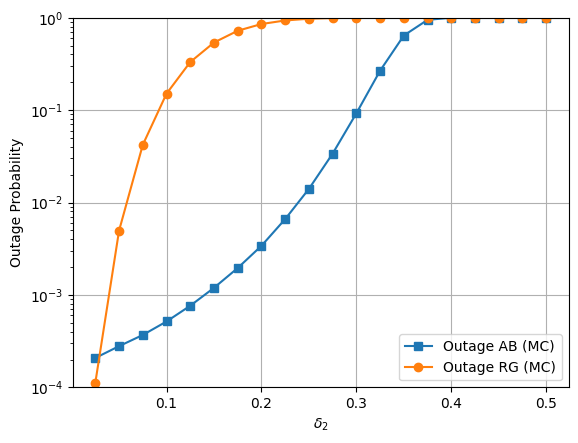

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv as besseli # Função de Bessel modificada (usada em análises teóricas)
from scipy.stats import ncx2            # Distribuição qui-quadrado não central (para Marcum-Q)
from scipy.integrate import quad        # Integração numérica

# Garante reprodutibilidade da simulação
np.random.seed(123456789)

# Implementação do Marcum-Q usando distribuição qui-quadrado não central
def marcumq(m, a, b):
  return 1 - ncx2.cdf(b**2, 2*m, a**2)

# ---------------- Parâmetros de potência ----------------
PG_dBm = 40                               # Potência do Power Beacon (PB) em dBm
PG = 10 ** ((PG_dBm - 30) / 10)           # Conversão para Watts

PA_dBm = 10                               # Potência dos nós A e B (dBm)
PA = 10 ** ((PA_dBm - 30) / 10)           # Watts
PB = PA                                   # Sistema simétrico

# ---------------- Ruído ----------------
N0_dBW_perHz = -204                       # Densidade espectral de ruído (dBW/Hz)
N0_linear = 10 ** (N0_dBW_perHz / 10)

Nf_dB = 10                                # Figura de ruído (dB)
Nf_linear = 10 ** (Nf_dB / 10)

B_Hz = 100e3                              # Banda do sistema (Hz)
noise_power = Nf_linear * N0_linear * B_Hz # Potência total de ruído

# ---------------- Constantes físicas ----------------
c_light = 3e8                             # Velocidade da luz (m/s)

# ---------------- Antenas ----------------
M_side = 3
M_ant = M_side ** 2                       # Total de antenas (arranjo 3x3)

# ---------------- Distâncias ----------------
d_GR_vec = 3                              # PB -> Relay
d_AB = 100                                # A <-> B
d_AR = 50                                 # A -> Relay
d_BR = 50                                 # B -> Relay
d_RG_vec = d_GR_vec                       # Relay -> PB (simétrico)

# ---------------- Path-loss ----------------
alpha_wet = 2                             # Exponente WET
f_wet = 915e6                             # Frequência WET

alpha_wit = 3                             # Expoente WIT
f_wit = 915e6                             # Frequência WIT

# ---------------- Fading Rician ----------------
K_wet_dB = 4
K_wet = 10 ** (K_wet_dB / 10)             # Fator K para WET

K_wit_dB = 2
K_wit = 10 ** (K_wit_dB / 10)             # Fator K para WIT

# ---------------- Energy Harvesting ----------------
eta_PAeff = 2 / 3                         # Eficiência do amplificador
P0_circ = 500e-6                          # Potência de circuito

# Parâmetros do modelo não linear de EH
c0 = 0.2308
c1 = 5.365
w_param = 10.73
Pmin_RF = 1e-4                            # Sensibilidade mínima

W_saturation = w_param * 1e-3             # Potência de saturação

# Função de conversão RF -> energia (modelo não linear)
def g_EH(P_RF):
    return W_saturation * (1 - np.exp(-c0 * (P_RF * 1e3))) / (1 + np.exp(-c0 * (P_RF * 1e3 - c1)))

# ---------------- Estrutura temporal ----------------
T_frame = 2                               # Duração total do frame (s)
delta1 = 0.4                              # Fração de tempo para WET
delta2_vector = np.arange(0.025, 0.525, 0.025) # Fração de tempo da fase 4

# ---------------- Monte Carlo ----------------
Nmc = int(1e6)                            # Número de amostras

Nd = len(delta2_vector)

# Vetores de saída
outA_sim = np.zeros(Nd)                   # Outage A->B
outR_sim = np.zeros(Nd)                   # Outage R->G
outA_th = np.zeros(Nd)
outR_th = np.zeros(Nd)

# índices das antenas (para beamforming)
idx_vec = np.arange(M_ant).reshape(-1, 1)

print("Starting Monte Carlo...")

# ================= LOOP PRINCIPAL =================
for id in range(Nd):
    delta2 = delta2_vector[id]

    # Divisão de energia entre fases
    mu_ratio = 0.85
    fracWIT123 = (1 - delta1 - delta2) / 3
    fracWIT4 = delta2
    fracDir = 0.5

    # -------- Modelo do capacitor --------
    tEH = delta1 * T_frame
    C_cap = 1e-3
    Resr = 160e-3
    Rfit = 901.8

    tau_C = C_cap * (Resr + Rfit)
    eff_charge = (1 - np.exp(-tEH / tau_C)) ** 2 # Eficiência de carregamento

    # -------- Threshold de SNR --------
    r_th_AB = 1
    r_th_RG = 0.5

    gammaTh_AB = 2 ** (r_th_AB / fracWIT123) - 1
    gammaTh_dir = 2 ** (r_th_AB / fracDir) - 1
    gammaTh_RG = 2 ** (r_th_RG / fracWIT4) - 1

    # -------- Path-loss --------
    beta_wet_GR = (c_light**2) / ((4*np.pi*f_wet)**2 * d_GR_vec**alpha_wet)
    beta_wit_AB = (c_light**2) / ((4*np.pi*f_wit)**2 * d_AB**alpha_wit)
    beta_wit_AR = (c_light**2) / ((4*np.pi*f_wit)**2 * d_AR**alpha_wit)
    beta_wit_BR = (c_light**2) / ((4*np.pi*f_wit)**2 * d_BR**alpha_wit)
    beta_wit_RG = (c_light**2) / ((4*np.pi*f_wit)**2 * d_RG_vec**alpha_wit)

    # ================= WET: Canal G → Relay =================
    az = 2 * np.pi * np.random.rand(Nmc)

    # Componente LOS (determinística)
    hLOS = np.sqrt(K_wet/(1+K_wet)) * np.exp(1j * (-np.pi) * idx_vec @ np.sin(az).reshape(1,-1))

    # Componente NLOS (ruído complexo gaussiano)
    hNLOS = np.sqrt(1/(1+K_wet)) * np.sqrt(0.5) * (np.random.randn(M_ant, Nmc) + 1j*np.random.randn(M_ant, Nmc))

    # Canal total
    hGR = hLOS + hNLOS

    # Beamforming (ganho efetivo)
    norm_hLOS = np.linalg.norm(hLOS, axis=0)
    proj = np.sum(np.conj(hLOS)*hNLOS, axis=0) / (norm_hLOS + 1e-12)

    # Potência RF recebida no relay
    PRF = PG * beta_wet_GR * np.abs(norm_hLOS + proj)**2

    # Aplicação da sensibilidade mínima
    PRF[PRF < Pmin_RF] = 0

    # Energia colhida
    E_R = eff_charge * delta1 * T_frame * np.maximum(0, g_EH(PRF))

    # Potência de transmissão do relay
    PR3 = np.maximum(0, eta_PAeff*(mu_ratio*E_R/(T_frame*fracWIT123) - P0_circ))
    PR4 = np.maximum(0, eta_PAeff*((1-mu_ratio)*E_R/(T_frame*fracWIT4) - P0_circ))

    # ================= WIT: Canais =================
    def rician(K, N):
        return np.sqrt(K/(1+K)) + np.sqrt(1/(1+K))*np.sqrt(0.5)*(np.random.randn(N)+1j*np.random.randn(N))

    h_AB = rician(K_wit, Nmc)
    h_AR = rician(K_wit, Nmc)
    h_BR = rician(K_wit, Nmc)

    # SNRs
    gamma_AB = PA * beta_wit_AB * np.abs(h_AB)**2 / noise_power
    gamma_AR = PA * beta_wit_AR * np.abs(h_AR)**2 / noise_power
    gamma_BR = PB * beta_wit_BR * np.abs(h_BR)**2 / noise_power

    # Relay -> A
    h_RA = rician(K_wit, Nmc)
    gamma_RA = PR3 * beta_wit_AR * np.abs(h_RA)**2 / noise_power

    # Relay -> G (MIMO com soma de ganhos)
    hLOS_RG = hLOS
    hNLOS_RG = np.sqrt(1/(1+K_wet)) * np.sqrt(0.5)*(np.random.randn(M_ant,Nmc)+1j*np.random.randn(M_ant,Nmc))
    hRG = hLOS_RG + hNLOS_RG

    gain_RG = np.sum(np.abs(hRG)**2, axis=0)
    gamma_RG = PR4 * beta_wit_RG * gain_RG / noise_power

    # ================= Outage =================
    # A→B via relay: produto das probabilidades de falha
    outA_sim[id] = np.mean(gamma_AB < gammaTh_AB) * np.mean(np.minimum(gamma_BR, gamma_RA) < gammaTh_AB)

    # Relay → G
    outR_sim[id] = np.mean(gamma_RG < gammaTh_RG)

print("Monte Carlo done")

# ================= Plot =================
plt.figure()

plt.semilogy(delta2_vector, outA_sim, 's-', label='Outage AB (MC)')
plt.semilogy(delta2_vector, outR_sim, 'o-', label='Outage RG (MC)')

plt.grid()
plt.xlabel(r'$\delta_2$')
plt.ylabel('Outage Probability')
plt.legend()
plt.ylim([1e-4, 1])

plt.show()